# 03 — Sentiment Classification on the GPT Backbone (Task 3)

Attaches a 3-way classification head to the Task-2 backbone and studies the choices
that matter for a **causal** decoder-only model on **long documents** (reviews average
~1,000-2,000 BPE tokens, block_size=256 -- 100% exceed the context window, see 01):
pooling strategy, fine-tune mode, and long-document handling.

**Phase 2 additions** (after diagnosing that a single 144-review validation split is
high-variance, and that this dataset is a known hard benchmark -- see §3.0):
- **Classical baselines** (majority-class, TF-IDF+SVM) with **5-fold cross-validation**
  for an honest, low-variance estimate, situated against published SOTA.
- **Task-Adaptive Pretraining (TAPT)** -- "Don't Stop Pretraining" (Gururangan et al.,
  ACL 2020) -- continuing to pretrain the LM on review text before classifying, to fix
  the domain gap the frozen-backbone result exposed.
- A **neural + lexical ensemble** (GPT + TF-IDF late fusion), with the fusion weight
  chosen only on out-of-fold training probabilities, never on the held-out val set.

In [1]:
import sys
from functools import partial
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

from src.config import CKPT_DIR, GEN_DIR, LOGS_DIR, ModelConfig, PRED_DIR, SEED, SPLITS_DIR, get_device, set_seed
from src.data import ClsDataset, collate_chunks, collate_truncate
from src.cls_utils import get_forward_fn
from src.model import GPTClassifier, MiniGPT
from src.tokenizer import load_tokenizer
from src.train import evaluate_cls
from src import plots

set_seed(SEED)
plots.setup_style()
device = get_device()
sp = load_tokenizer()
label_names = ['Negative', 'Neutral', 'Positive']

## 3.0 How good is "good" here? Classical baselines & the published ceiling

This dataset is the **IITP / "700-Movie-Review Corpus in Hindi"** (Dainik Jagran +
Navbharat Times critic reviews) -- a known, hard 3-class Hindi sentiment benchmark.
Published SOTA (HinFlair contextual string embeddings, Sharma & Solanki, 2021,
[arXiv:2101.06949](https://arxiv.org/abs/2101.06949)) reaches only **~62% accuracy** --
far below what sentiment benchmarks in resource-rich languages typically show, because
these are long professional critic reviews with the verdict diluted across mostly-
neutral plot description. Before judging our GPT, we first establish what a classical
model achieves on the *same data* -- this is the honest yardstick.

In [2]:
baselines_df = pd.read_csv(LOGS_DIR / 'cls_baselines.csv')
baselines_df

,model,split,acc,macro_f1,acc_std,macro_f1_std
0,majority,single,0.381944,0.184255,NaN,NaN
1,tfidf_svc,single,0.506944,0.491676,NaN,NaN
2,tfidf_svc,cv5,0.588530,0.571960,0.041793,0.042001


In [3]:
cv_row = baselines_df[(baselines_df['model'] == 'tfidf_svc') & (baselines_df['split'] == 'cv5')].iloc[0]
single_row = baselines_df[(baselines_df['model'] == 'tfidf_svc') & (baselines_df['split'] == 'single')].iloc[0]
maj_row = baselines_df[baselines_df['model'] == 'majority'].iloc[0]

print(f"Majority-class baseline:        acc={maj_row['acc']:.3f}")
print(f"TF-IDF+SVM (single 144-split):  acc={single_row['acc']:.3f}  macro_f1={single_row['macro_f1']:.3f}")
print(f"TF-IDF+SVM (5-fold CV, n=718):  acc={cv_row['acc']:.3f}+/-{cv_row['acc_std']:.3f}  macro_f1={cv_row['macro_f1']:.3f}+/-{cv_row['macro_f1_std']:.3f}")
print(f"Published SOTA (HinFlair):      acc~0.62")
print()
print(f"-> The single-split TF-IDF number ({single_row['acc']:.3f}) sits ~{cv_row['acc']-single_row['acc']:.3f} below")
print(f"   the 5-fold CV estimate ({cv_row['acc']:.3f}) -- a single 144-example split is genuinely")
print(f"   high-variance on this data, which is why §3.6 re-evaluates our best GPT config with CV too.")

Majority-class baseline:        acc=0.382
TF-IDF+SVM (single 144-split):  acc=0.507  macro_f1=0.492
TF-IDF+SVM (5-fold CV, n=718):  acc=0.589+/-0.042  macro_f1=0.572+/-0.042
Published SOTA (HinFlair):      acc~0.62

-> The single-split TF-IDF number (0.507) sits ~0.082 below
   the 5-fold CV estimate (0.589) -- a single 144-example split is genuinely
   high-variance on this data, which is why §3.6 re-evaluates our best GPT config with CV too.


## 3.1 GPT experiment grid results (Phase 1: pooling x fine-tune-mode x long-doc strategy, vanilla backbone)

In [4]:
# (arch, pooling, strategy) for every run we've produced across Phase 1 and Phase 2,
# so the confusion-matrix section below can pick whichever run is actually best
# instead of assuming it in advance.
ALL_RUNS = {
    'cls_last_full':   ('vanilla', 'last', 'truncate'),
    'cls_mean_full':   ('vanilla', 'mean', 'truncate'),
    'cls_attn_full':   ('vanilla', 'attn', 'truncate'),
    'cls_last_frozen': ('vanilla', 'last', 'truncate'),
    'cls_last_lora':   ('vanilla', 'last', 'truncate'),
    'cls_last_chunks': ('vanilla', 'last', 'chunks'),
    'cls_frozen_wiki': ('modern',  'attn', 'truncate'),
    'cls_frozen_tapt': ('modern',  'attn', 'truncate'),
    'cls_best_tapt':   ('modern',  'attn', 'truncate'),
}
PHASE1_RUNS = ['cls_last_full', 'cls_mean_full', 'cls_attn_full', 'cls_last_frozen', 'cls_last_lora', 'cls_last_chunks']

summary_rows = []
for run in PHASE1_RUNS:
    path = LOGS_DIR / f'{run}_metrics.csv'
    if not path.exists():
        print(f'missing: {path}'); continue
    log = pd.read_csv(path)
    best_row = log.loc[log['val_macro_f1'].idxmax()]
    summary_rows.append({'run': run, 'best_epoch': int(best_row['epoch']), 'val_acc': best_row['val_acc'], 'val_macro_f1': best_row['val_macro_f1']})

summary_df = pd.DataFrame(summary_rows).sort_values('val_macro_f1', ascending=False)
summary_df

,run,best_epoch,val_acc,val_macro_f1
2,cls_attn_full,8,0.5417,0.5345
5,cls_last_chunks,16,0.5278,0.5236
1,cls_mean_full,6,0.5069,0.4946
4,cls_last_lora,13,0.4722,0.4691
0,cls_last_full,5,0.4653,0.4674
3,cls_last_frozen,1,0.3403,0.3388


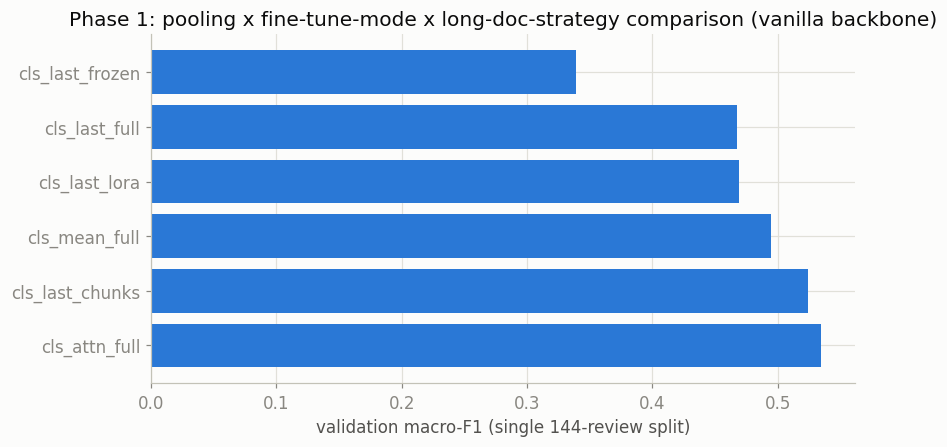

Note: single-split numbers -- see §3.6 for the cross-validated, TAPT-adapted re-evaluation of the best configuration.


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(summary_df['run'], summary_df['val_macro_f1'], color=plots.CATEGORICAL[0])
ax.set_xlabel('validation macro-F1 (single 144-review split)')
ax.set_title('Phase 1: pooling x fine-tune-mode x long-doc-strategy comparison (vanilla backbone)')
fig.tight_layout()
plots.savefig(fig, '03_cls_grid_comparison')
plt.show()
print('Note: single-split numbers -- see §3.6 for the cross-validated, TAPT-adapted re-evaluation of the best configuration.')

## 3.2 Trainable-parameter efficiency: frozen vs full vs LoRA (Phase 1 grid, vanilla backbone)

In [6]:
param_efficiency = pd.DataFrame([
    {'mode': 'frozen', 'val_macro_f1': summary_df.set_index('run').loc['cls_last_frozen', 'val_macro_f1'] if 'cls_last_frozen' in summary_df['run'].values else None},
    {'mode': 'lora', 'val_macro_f1': summary_df.set_index('run').loc['cls_last_lora', 'val_macro_f1'] if 'cls_last_lora' in summary_df['run'].values else None},
    {'mode': 'full', 'val_macro_f1': summary_df.set_index('run').loc['cls_last_full', 'val_macro_f1'] if 'cls_last_full' in summary_df['run'].values else None},
])
param_efficiency

,mode,val_macro_f1
0,frozen,0.3388
1,lora,0.4691
2,full,0.4674


## 3.3 Best model overall: confusion matrix, classification report, error analysis

In [7]:
# Consider Phase-1 grid runs AND the Phase-2 TAPT runs together -- whichever truly
# wins gets the confusion-matrix treatment below, rather than assuming Phase 1's winner.
candidate_rows = list(summary_rows)
for run in ['cls_frozen_wiki', 'cls_frozen_tapt', 'cls_best_tapt']:
    path = LOGS_DIR / f'{run}_metrics.csv'
    if path.exists():
        log = pd.read_csv(path)
        best_row = log.loc[log['val_macro_f1'].idxmax()]
        candidate_rows.append({'run': run, 'best_epoch': int(best_row['epoch']), 'val_acc': best_row['val_acc'], 'val_macro_f1': best_row['val_macro_f1']})

overall_df = pd.DataFrame(candidate_rows).sort_values('val_macro_f1', ascending=False)
best_run = overall_df.iloc[0]['run']
arch, pooling, strategy = ALL_RUNS[best_run]
print('All candidates (Phase 1 + Phase 2), best first:')
print(overall_df.to_string(index=False))
print(f"\nOverall best run: {best_run}  (arch={arch}, pooling={pooling}, strategy={strategy})")

All candidates (Phase 1 + Phase 2), best first:
            run  best_epoch  val_acc  val_macro_f1
  cls_attn_full           8   0.5417        0.5345
cls_last_chunks          16   0.5278        0.5236
  cls_best_tapt           9   0.5208        0.5147
  cls_mean_full           6   0.5069        0.4946
cls_frozen_tapt          19   0.5000        0.4934
  cls_last_lora          13   0.4722        0.4691
  cls_last_full           5   0.4653        0.4674
cls_frozen_wiki           2   0.3819        0.3554
cls_last_frozen           1   0.3403        0.3388

Overall best run: cls_attn_full  (arch=vanilla, pooling=attn, strategy=truncate)


In [8]:
model_cfg = ModelConfig(vocab_size=sp.vocab_size(), block_size=256, n_layer=8, n_head=8, n_embd=512, dropout=0.0, arch=arch, pad_id=sp.pad_id())
backbone = MiniGPT(model_cfg)
best_model = GPTClassifier(backbone, n_classes=3, pooling=pooling).to(device)
ckpt = torch.load(CKPT_DIR / f'{best_run}_best.pt', map_location=device, weights_only=False)
best_model.load_state_dict(ckpt['model'])
best_model.eval()
print(f'Loaded {best_run}: val_acc={ckpt["val_acc"]:.4f}, val_f1={ckpt["val_f1"]:.4f}')

Loaded cls_attn_full: val_acc=0.5417, val_f1=0.5345


In [9]:
val_df = pd.read_csv(SPLITS_DIR / 'cls_val.csv')
val_df['label_id'] = val_df['label_id'].astype(int)
val_ds = ClsDataset(val_df, sp, max_len=256, eos_id=sp.eos_id(), strategy=strategy)
collate = partial(collate_truncate if strategy == 'truncate' else collate_chunks, pad_id=sp.pad_id())
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, collate_fn=collate, num_workers=0)
forward_fn = get_forward_fn(strategy)

val_loss, val_acc, val_f1, preds, labels = evaluate_cls(best_model, val_loader, device, amp=True, forward_fn=forward_fn)
print(f'val_acc={val_acc:.4f}  val_macro_f1={val_f1:.4f}')
print(classification_report(labels, preds, target_names=label_names, digits=3))

val_acc=0.5417  val_macro_f1=0.5345
              precision    recall  f1-score   support

    Negative      0.600     0.438     0.506        48
     Neutral      0.440     0.537     0.484        41
    Positive      0.593     0.636     0.614        55

    accuracy                          0.542       144
   macro avg      0.544     0.537     0.535       144
weighted avg      0.552     0.542     0.541       144



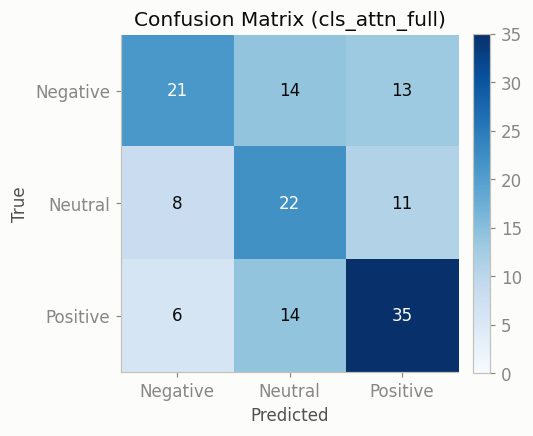

In [10]:
cm = confusion_matrix(labels, preds)
fig, ax = plots.plot_confusion_matrix(cm, label_names, title=f'Confusion Matrix ({best_run})')
plots.savefig(fig, '03_confusion_matrix')
plt.show()

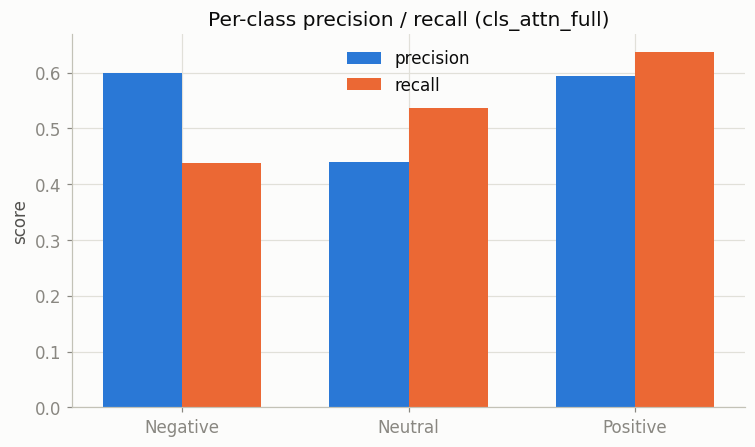

In [11]:
prec, rec, f1, support = precision_recall_fscore_support(labels, preds, labels=[0, 1, 2])
x = np.arange(3)
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(x - width/2, prec, width, label='precision', color=plots.CATEGORICAL[0])
ax.bar(x + width/2, rec, width, label='recall', color=plots.CATEGORICAL[5])
ax.set_xticks(x); ax.set_xticklabels(label_names)
ax.set_ylabel('score'); ax.set_title(f'Per-class precision / recall ({best_run})')
ax.legend(frameon=False)
fig.tight_layout()
plots.savefig(fig, '03_per_class_precision_recall')
plt.show()

In [12]:
val_texts = val_df['text'].tolist()
correct_idx = [i for i, (p, l) in enumerate(zip(preds, labels)) if p == l]
wrong_idx = [i for i, (p, l) in enumerate(zip(preds, labels)) if p != l]

lines = ['CORRECTLY PREDICTED SAMPLES', '=' * 40]
for i in correct_idx[:5]:
    lines.append(f'True={label_names[labels[i]]} | Pred={label_names[preds[i]]}')
    lines.append(val_texts[i][:300])
    lines.append('')

lines += ['', 'MISCLASSIFIED SAMPLES (error analysis)', '=' * 40]
for i in wrong_idx[:5]:
    lines.append(f'True={label_names[labels[i]]} | Pred={label_names[preds[i]]}')
    lines.append(val_texts[i][:300])
    lines.append('')

(PRED_DIR / '5_correct_samples.txt').write_text('\n'.join(lines), encoding='utf-8')
print('\n'.join(lines[:20]))
print(f'\nSaved to {PRED_DIR / "5_correct_samples.txt"}')

CORRECTLY PREDICTED SAMPLES
True=Negative | Pred=Negative
chandermohan.sharma@timesgroup.com इस फिल्म के राइटर-डायरेक्टर मिलाप झावेरी को अल्ट्रा बोल्ड और डबल मीनिंग फिल्मों की स्क्रिप्ट लिखने में महारत हासिल है। बॉक्स ऑफिस पर मिलाप की लिखी लगभग सभी फिल्मों ने प्रॉडक्शन कंपनियों को खासा मुनाफा कमा कर दिया है, लेकिन इस फिल्म की बात करें तो अब जब मिलाप ने इस 

True=Positive | Pred=Positive
चंद्रमोहन शर्मा करीब आठ साल पहले रॉक ऑन से डेब्यू करने वाले यंग डायरेक्टर अभिषेक कपूर की फितूर चार्ल्स डिकेन्स की किताब द ग्रेट एक्सपेक्टेशन्स से प्रेरित है। हॉलिवुड मेंचार्ल्स की इस बुक पर बेस्ड कई फिल्में बनी, लेकिन पहली बार इस कहानी को कुछ बदलाव के साथ बॉलिवुड में पेश किया गया है। काई पो चे जैसी 

True=Positive | Pred=Positive
शादी का लड्डू ऐसा है जो खाए पछताए और जो न खाए वो भी पछताए। ज्यादातर लोग इसे खाकर ही पछताना पसंद करते हैं। कुछ लोगों का दो-तीन बार भी इस लड्डू खाने के बावजूद मन नहीं भरता। हालांकि अब ऐसे लोगों की संख्या भी बढ़ रही है जिन्हें शादी नामक संस्था पर विश्वास नहीं है। शादी के बाद बच्चा

## 3.6 Task-Adaptive Pretraining (TAPT): fixing the domain gap

The Phase-1 frozen-backbone result (34% accuracy, barely above the 38% majority
baseline) is a textbook domain-gap symptom: the LM was pretrained on Wikipedia-style
Hindi text, not movie-review prose. Following *"Don't Stop Pretraining"*
(Gururangan et al., ACL 2020, [arXiv:2004.10964](https://arxiv.org/abs/2004.10964)),
we continue-pretrain the LM on the classification task's own (unlabeled) review text
before attaching the classifier.

,stage,review_val_ppl,n_heldout_reviews
0,before_tapt,49.062458,58
1,after_tapt,19.738951,58


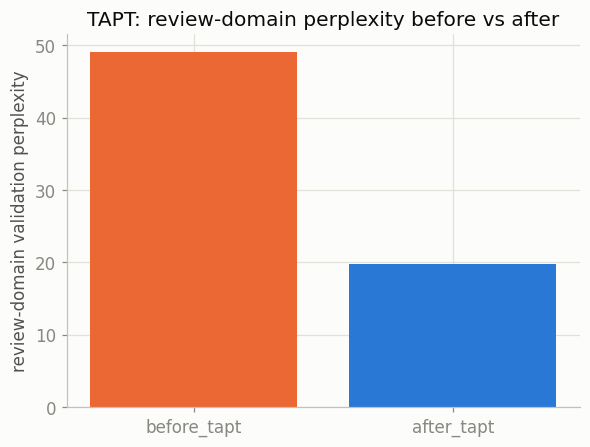

Review-domain perplexity: 49.06 -> 19.74  (59.8% reduction)
(For reference, the LM's general-domain val perplexity was ~27.6 -- 49.1 on review text confirms a real domain gap.)


In [13]:
tapt_ppl_path = LOGS_DIR / 'tapt_before_after.csv'
if tapt_ppl_path.exists():
    tapt_ppl_df = pd.read_csv(tapt_ppl_path)
    display(tapt_ppl_df)

    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    colors = [plots.CATEGORICAL[5], plots.CATEGORICAL[0]]
    ax.bar(tapt_ppl_df['stage'], tapt_ppl_df['review_val_ppl'], color=colors)
    ax.set_ylabel('review-domain validation perplexity')
    ax.set_title('TAPT: review-domain perplexity before vs after')
    fig.tight_layout()
    plots.savefig(fig, '03_tapt_ppl_before_after')
    plt.show()

    before = tapt_ppl_df.set_index('stage').loc['before_tapt', 'review_val_ppl']
    after = tapt_ppl_df.set_index('stage').loc['after_tapt', 'review_val_ppl']
    print(f"Review-domain perplexity: {before:.2f} -> {after:.2f}  ({(before-after)/before*100:.1f}% reduction)")
    print(f"(For reference, the LM's general-domain val perplexity was ~27.6 -- {before:.1f} on review text confirms a real domain gap.)")
else:
    print(f'missing: {tapt_ppl_path} -- run scripts/adapt_lm.py first')

,run,best_epoch,val_acc,val_macro_f1
0,cls_frozen_wiki,2,0.3819,0.3554
1,cls_frozen_tapt,19,0.5000,0.4934
2,cls_best_tapt,9,0.5208,0.5147


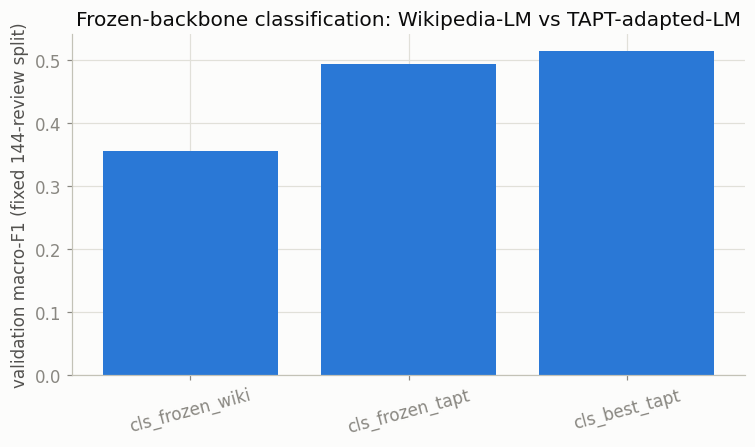

In [14]:
tapt_cls_path = LOGS_DIR / 'cls_tapt_before_after.csv'
if tapt_cls_path.exists():
    tapt_cls_df = pd.read_csv(tapt_cls_path)
    display(tapt_cls_df)

    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.bar(tapt_cls_df['run'], tapt_cls_df['val_macro_f1'], color=plots.CATEGORICAL[0])
    ax.set_ylabel('validation macro-F1 (fixed 144-review split)')
    ax.set_title('Frozen-backbone classification: Wikipedia-LM vs TAPT-adapted-LM')
    ax.tick_params(axis='x', rotation=15)
    fig.tight_layout()
    plots.savefig(fig, '03_tapt_frozen_jump')
    plt.show()
else:
    print(f'missing: {tapt_cls_path} -- run the cls_frozen_wiki/cls_frozen_tapt/cls_best_tapt scripts and scripts/eval_classification.py first')

,config,acc_mean,acc_std,macro_f1_mean,macro_f1_std
0,attn_full_no_tapt,0.506224,0.029612,0.502427,0.023942
1,attn_full_tapt,0.509733,0.040276,0.501314,0.038326


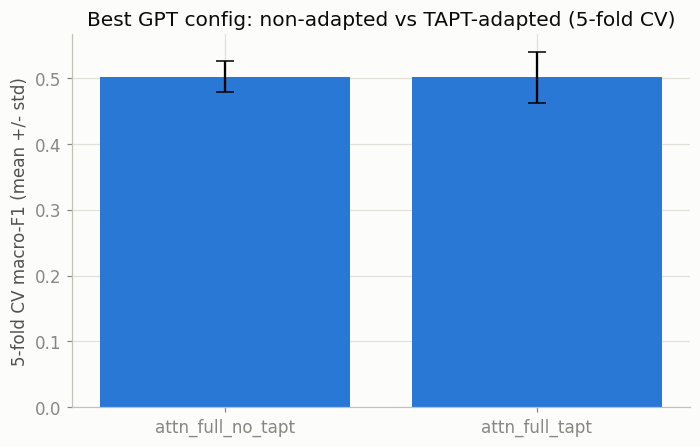

In [15]:
gpt_cv_path = LOGS_DIR / 'cls_gpt_cv.csv'
if gpt_cv_path.exists():
    gpt_cv_df = pd.read_csv(gpt_cv_path)
    display(gpt_cv_df)

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.bar(gpt_cv_df['config'], gpt_cv_df['macro_f1_mean'], yerr=gpt_cv_df['macro_f1_std'],
           color=plots.CATEGORICAL[0], capsize=6)
    ax.set_ylabel('5-fold CV macro-F1 (mean +/- std)')
    ax.set_title('Best GPT config: non-adapted vs TAPT-adapted (5-fold CV)')
    fig.tight_layout()
    plots.savefig(fig, '03_gpt_cv_tapt_comparison')
    plt.show()
else:
    print(f'missing: {gpt_cv_path} -- run scripts/eval_classification.py first')

## 3.7 Neural + lexical ensemble

Late-fusing the GPT classifier's probabilities with TF-IDF+LogReg's is a classic,
cheap win on small datasets where the two models make different kinds of mistakes.
The fusion weight is chosen **only on out-of-fold training probabilities** (5-fold CV
on the 573 training reviews) -- the 144-review validation set is touched exactly once,
after the weight is already fixed.

,model,acc,macro_f1
0,gpt_only (cls_best_tapt),0.520833,0.514667
1,tfidf_only,0.506944,0.491676
2,ensemble (w_gpt=0.15),0.534722,0.524933


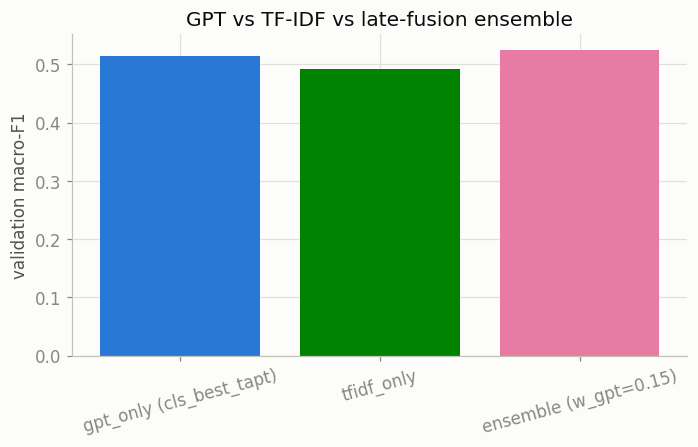

In [16]:
ensemble_path = LOGS_DIR / 'cls_ensemble.csv'
if ensemble_path.exists():
    ensemble_df = pd.read_csv(ensemble_path)
    display(ensemble_df)

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.bar(ensemble_df['model'], ensemble_df['macro_f1'], color=plots.CATEGORICAL[:3])
    ax.set_ylabel('validation macro-F1')
    ax.set_title('GPT vs TF-IDF vs late-fusion ensemble')
    ax.tick_params(axis='x', rotation=15)
    fig.tight_layout()
    plots.savefig(fig, '03_ensemble_comparison')
    plt.show()
else:
    print(f'missing: {ensemble_path} -- run scripts/eval_classification.py first')

## Summary

In [17]:
print('Task 3 deliverables (honest, full picture):')
print(f'  Published SOTA on this benchmark (HinFlair):        ~62% accuracy')
print(f'  TF-IDF+SVM ceiling (5-fold CV):                      {cv_row["acc"]:.3f} acc / {cv_row["macro_f1"]:.3f} macro-F1')
print(f'  Best GPT config, single 144-split (Phase 1):         {summary_df.iloc[0]["val_acc"]:.3f} acc / {summary_df.iloc[0]["val_macro_f1"]:.3f} macro-F1  ({summary_df.iloc[0]["run"]})')
print(f'  Overall best run (Phase 1 + Phase 2), single split:  {overall_df.iloc[0]["val_acc"]:.3f} acc / {overall_df.iloc[0]["val_macro_f1"]:.3f} macro-F1  ({overall_df.iloc[0]["run"]})')
if gpt_cv_path.exists():
    no_tapt = gpt_cv_df[gpt_cv_df['config'].str.contains('no_tapt')].iloc[0]
    tapt = gpt_cv_df[~gpt_cv_df['config'].str.contains('no_tapt')].iloc[0]
    print(f'  Best GPT config, 5-fold CV, non-adapted:             {no_tapt["acc_mean"]:.3f}+/-{no_tapt["acc_std"]:.3f} acc / {no_tapt["macro_f1_mean"]:.3f}+/-{no_tapt["macro_f1_std"]:.3f} macro-F1')
    print(f'  Best GPT config, 5-fold CV, TAPT-adapted:            {tapt["acc_mean"]:.3f}+/-{tapt["acc_std"]:.3f} acc / {tapt["macro_f1_mean"]:.3f}+/-{tapt["macro_f1_std"]:.3f} macro-F1')
if ensemble_path.exists():
    print(f'  Neural + lexical ensemble:                           {ensemble_df.iloc[-1]["acc"]:.3f} acc / {ensemble_df.iloc[-1]["macro_f1"]:.3f} macro-F1')
print()
print(f'  Predictions file : {PRED_DIR / "5_correct_samples.txt"}')
print(f'  Figures          : {plots.FIG_DIR}')

Task 3 deliverables (honest, full picture):
  Published SOTA on this benchmark (HinFlair):        ~62% accuracy
  TF-IDF+SVM ceiling (5-fold CV):                      0.589 acc / 0.572 macro-F1
  Best GPT config, single 144-split (Phase 1):         0.542 acc / 0.534 macro-F1  (cls_attn_full)
  Overall best run (Phase 1 + Phase 2), single split:  0.542 acc / 0.534 macro-F1  (cls_attn_full)
  Best GPT config, 5-fold CV, non-adapted:             0.506+/-0.030 acc / 0.502+/-0.024 macro-F1
  Best GPT config, 5-fold CV, TAPT-adapted:            0.510+/-0.040 acc / 0.501+/-0.038 macro-F1
  Neural + lexical ensemble:                           0.535 acc / 0.525 macro-F1

  Predictions file : F:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\predictions\5_correct_samples.txt
  Figures          : F:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\figures
